In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA

In [3]:
df = pd.read_excel("EastWestAirlines.xlsx",sheet_name=1)
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID#,3999.0,2014.819455,1160.764358,1.0,1010.5,2016.0,3020.5,4021.0
Balance,3999.0,73601.327582,100775.664958,0.0,18527.5,43097.0,92404.0,1704838.0
Qual_miles,3999.0,144.114529,773.663804,0.0,0.0,0.0,0.0,11148.0
cc1_miles,3999.0,2.059515,1.376919,1.0,1.0,1.0,3.0,5.0
cc2_miles,3999.0,1.014504,0.147650,1.0,1.0,1.0,1.0,3.0
cc3_miles,3999.0,1.012253,0.195241,1.0,1.0,1.0,1.0,5.0
Bonus_miles,3999.0,17144.846212,24150.967826,0.0,1250.0,7171.0,23800.5,263685.0
Bonus_trans,3999.0,11.601900,9.603810,0.0,3.0,12.0,17.0,86.0
Flight_miles_12mo,3999.0,460.055764,1400.209171,0.0,0.0,0.0,311.0,30817.0
Flight_trans_12,3999.0,1.373593,3.793172,0.0,0.0,0.0,1.0,53.0


In [6]:
# Check for missing values
print(df.isnull().sum())

# Mssing values exist, fill them
df.fillna(df.median(), inplace=True)

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [7]:
df_original = df.copy()

In [9]:
# Keep only numeric columns for clustering (most airline datasets have numeric features)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df1 = df[num_cols].copy()

## Outlier Detection & Visualization

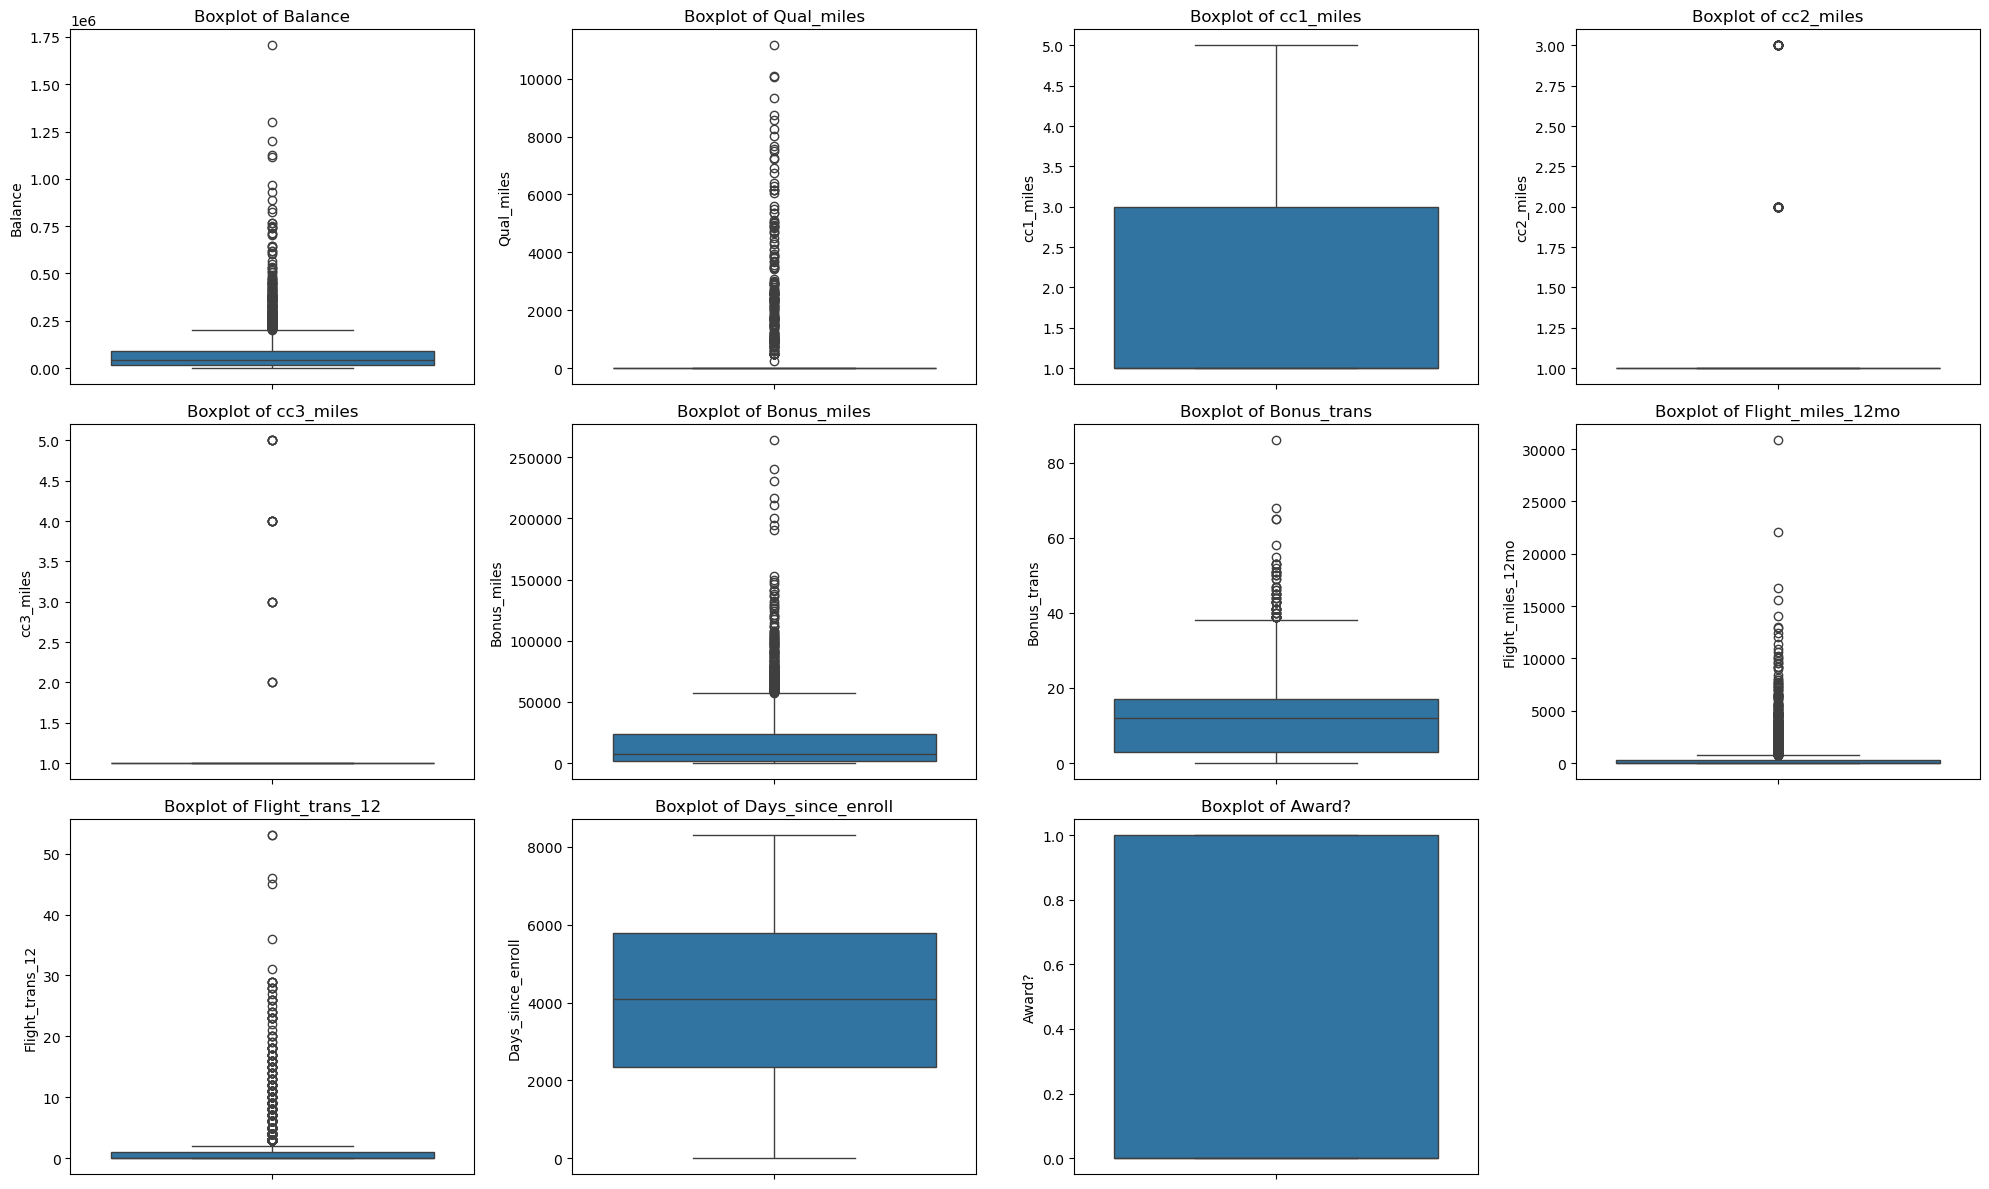

In [12]:
# Boxplots for all numerical features
plt.figure(figsize=(20,12))
for i, col in enumerate(df.columns[1:],1): 
    plt.subplot(3,4,i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


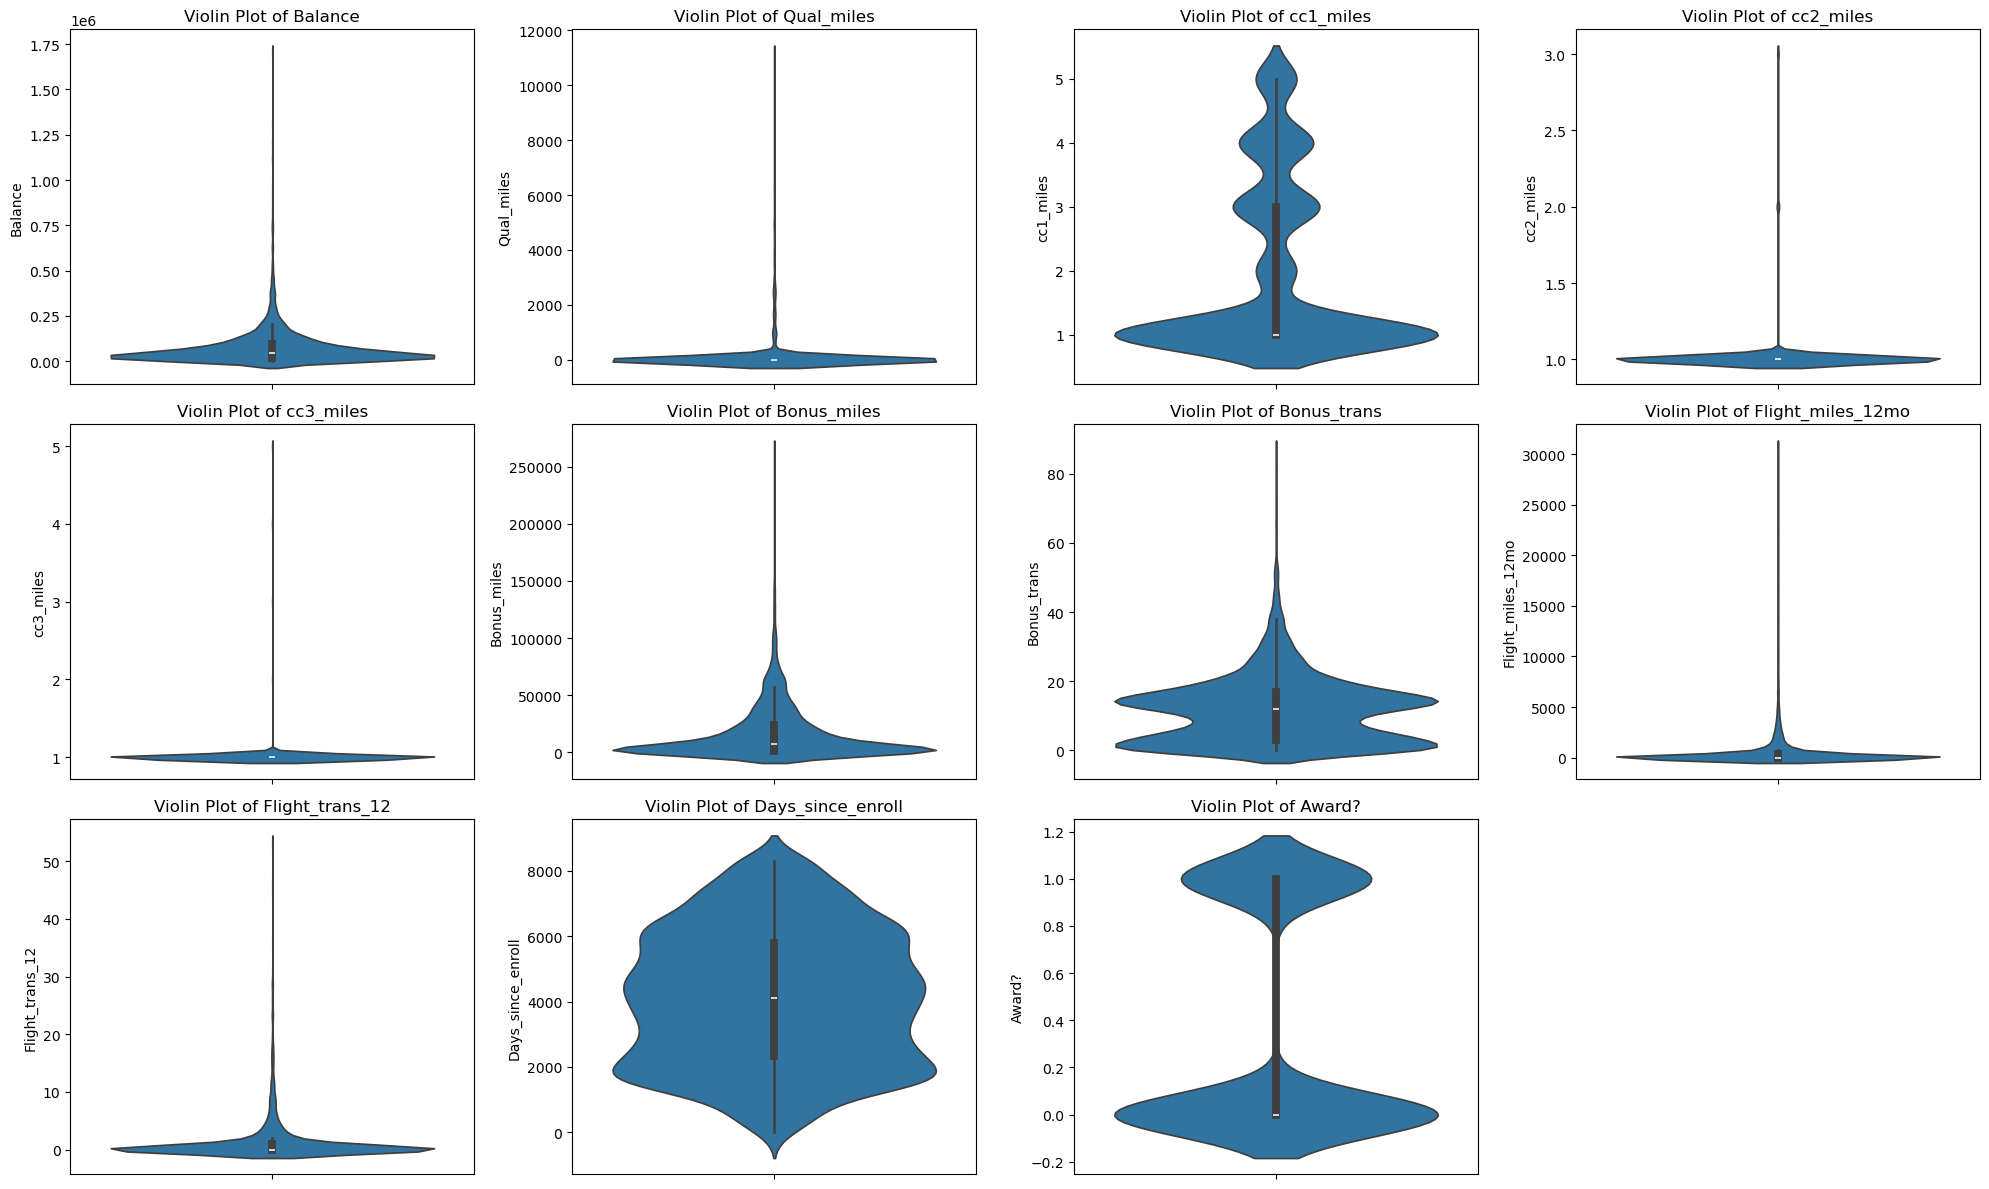

In [13]:
# Violin plots to visualize distribution and density
plt.figure(figsize=(20,12))
for i, col in enumerate(df.columns[1:],1):
    plt.subplot(3,4,i)
    sns.violinplot(y=df[col])
    plt.title(f'Violin Plot of {col}')
plt.tight_layout()
plt.show()


### Remove Outliners using IQR

In [14]:
# IQR method for outlier removal
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Keep only rows within 1.5*IQR range
df_clean = df[~((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).any(axis=1)].reset_index(drop=True)

print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original shape: (3999, 12)
After removing outliers: (2875, 12)


### Feature Scaling

In [15]:
# Drop ID# and Award? before scaling
df_cluster = df_clean.drop(['ID#', 'Award?'], axis=1)

# Standardize features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
print("Feature scaling example:\n", df_scaled[:5])

# Convert back to DataFrame for clarity
df_scaled = pd.DataFrame(df_scaled, columns=df_cluster.columns)
df_scaled.head()


Feature scaling example:
 [[-0.43885929  0.         -0.71905467  0.          0.         -0.78313072
  -1.08173169 -0.37883719 -0.40970772  1.50369284]
 [-0.64773487  0.         -0.71905467  0.          0.         -0.78012963
  -0.9527351  -0.37883719 -0.40970772  1.48803468]
 [-0.1287733   0.         -0.71905467  0.          0.         -0.49407535
  -0.69474194 -0.37883719 -0.40970772  1.52032964]
 [-0.75260689  0.         -0.71905467  0.          0.         -0.75926846
  -1.08173169 -0.37883719 -0.40970772  1.4802056 ]
 [-0.71401924  0.         -0.71905467  0.          0.         -0.79586701
  -1.21072827 -0.37883719 -0.40970772  1.47531242]]


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693
1,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035
2,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330
3,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206
4,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312


### Exploratary Data Analysis(EDA)

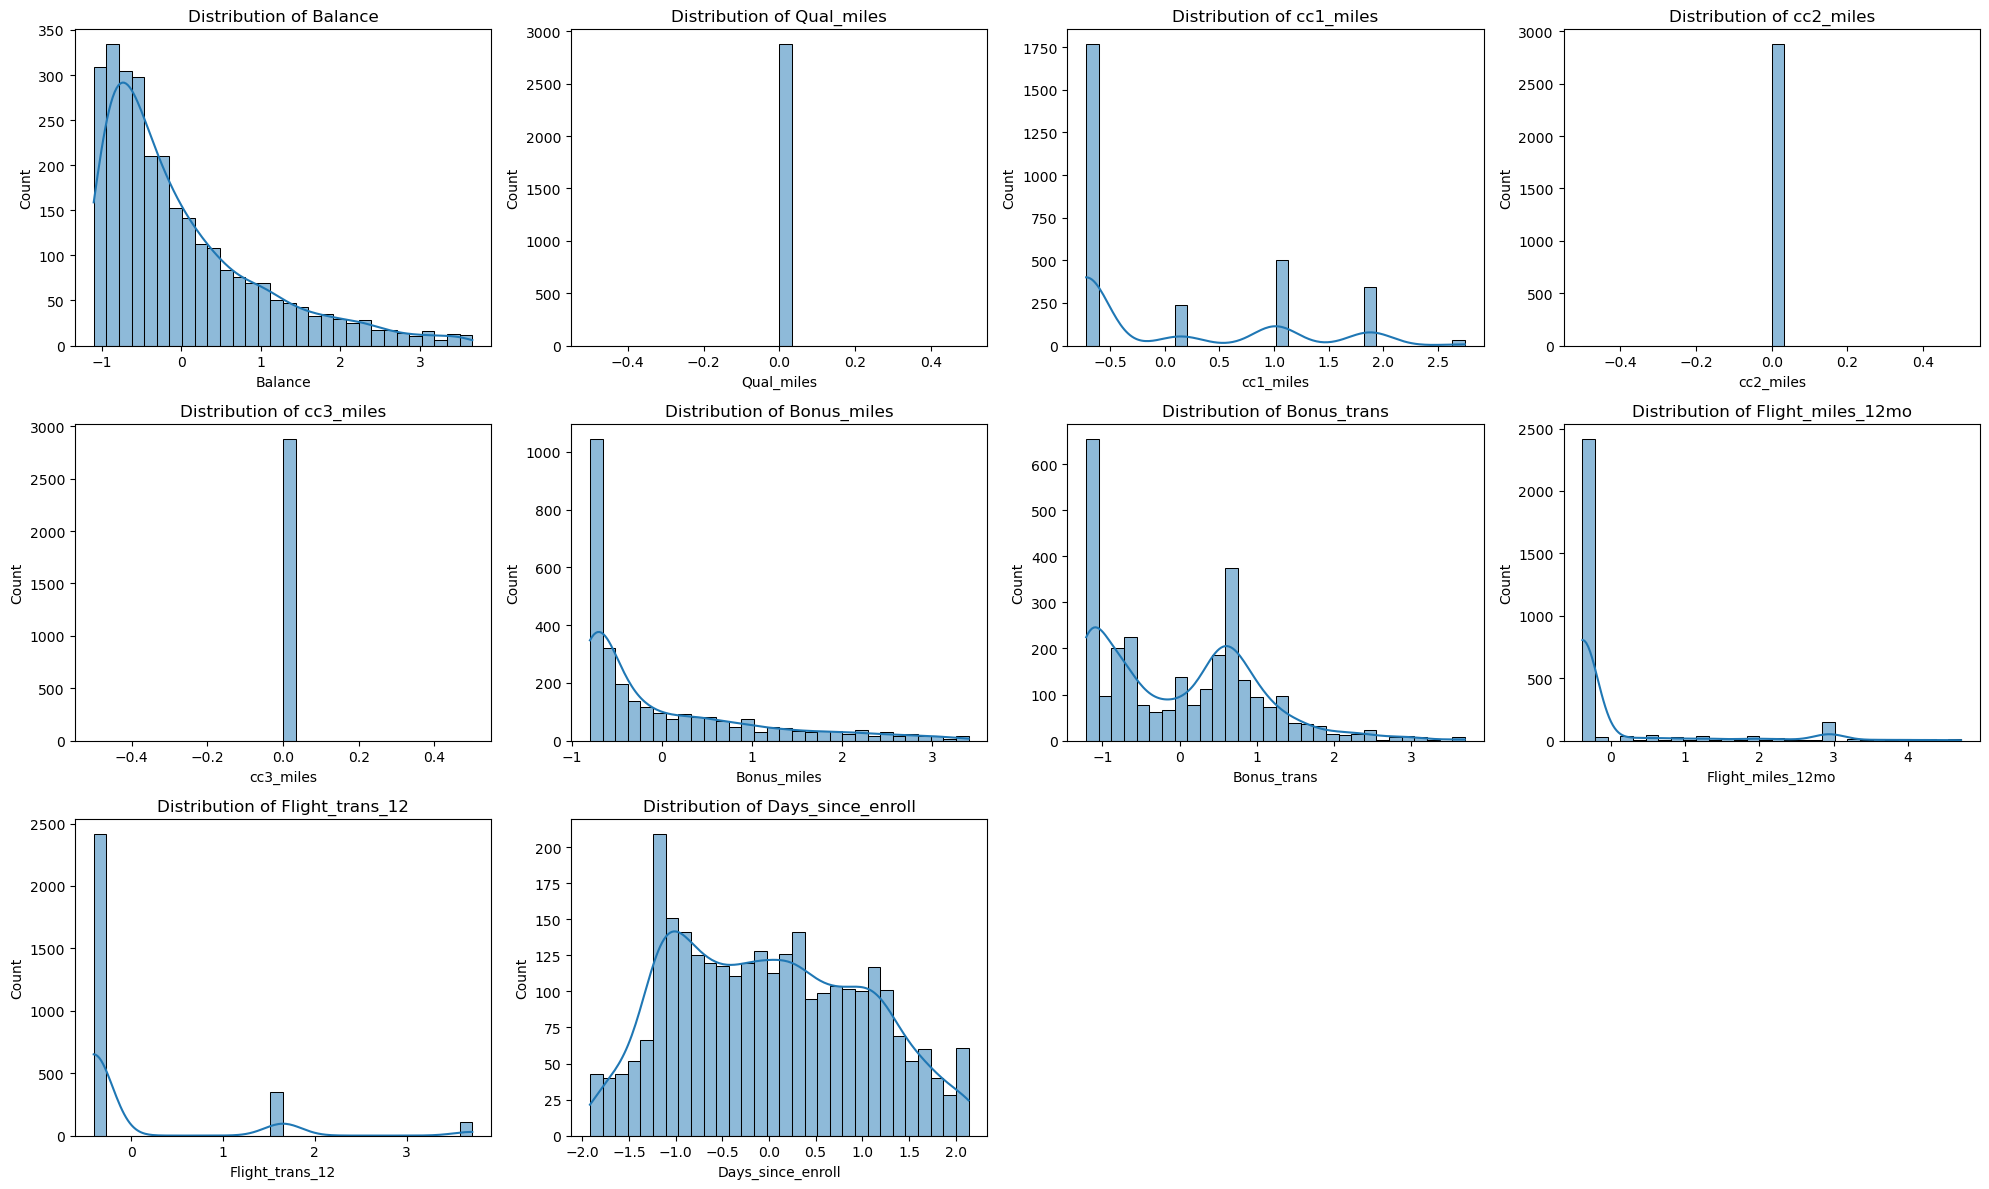

In [18]:
# Histograms to understand the distribution of each feature
plt.figure(figsize=(20,12))
for i, col in enumerate(df_scaled.columns, 1):
    plt.subplot(3,4,i)
    sns.histplot(df_scaled[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


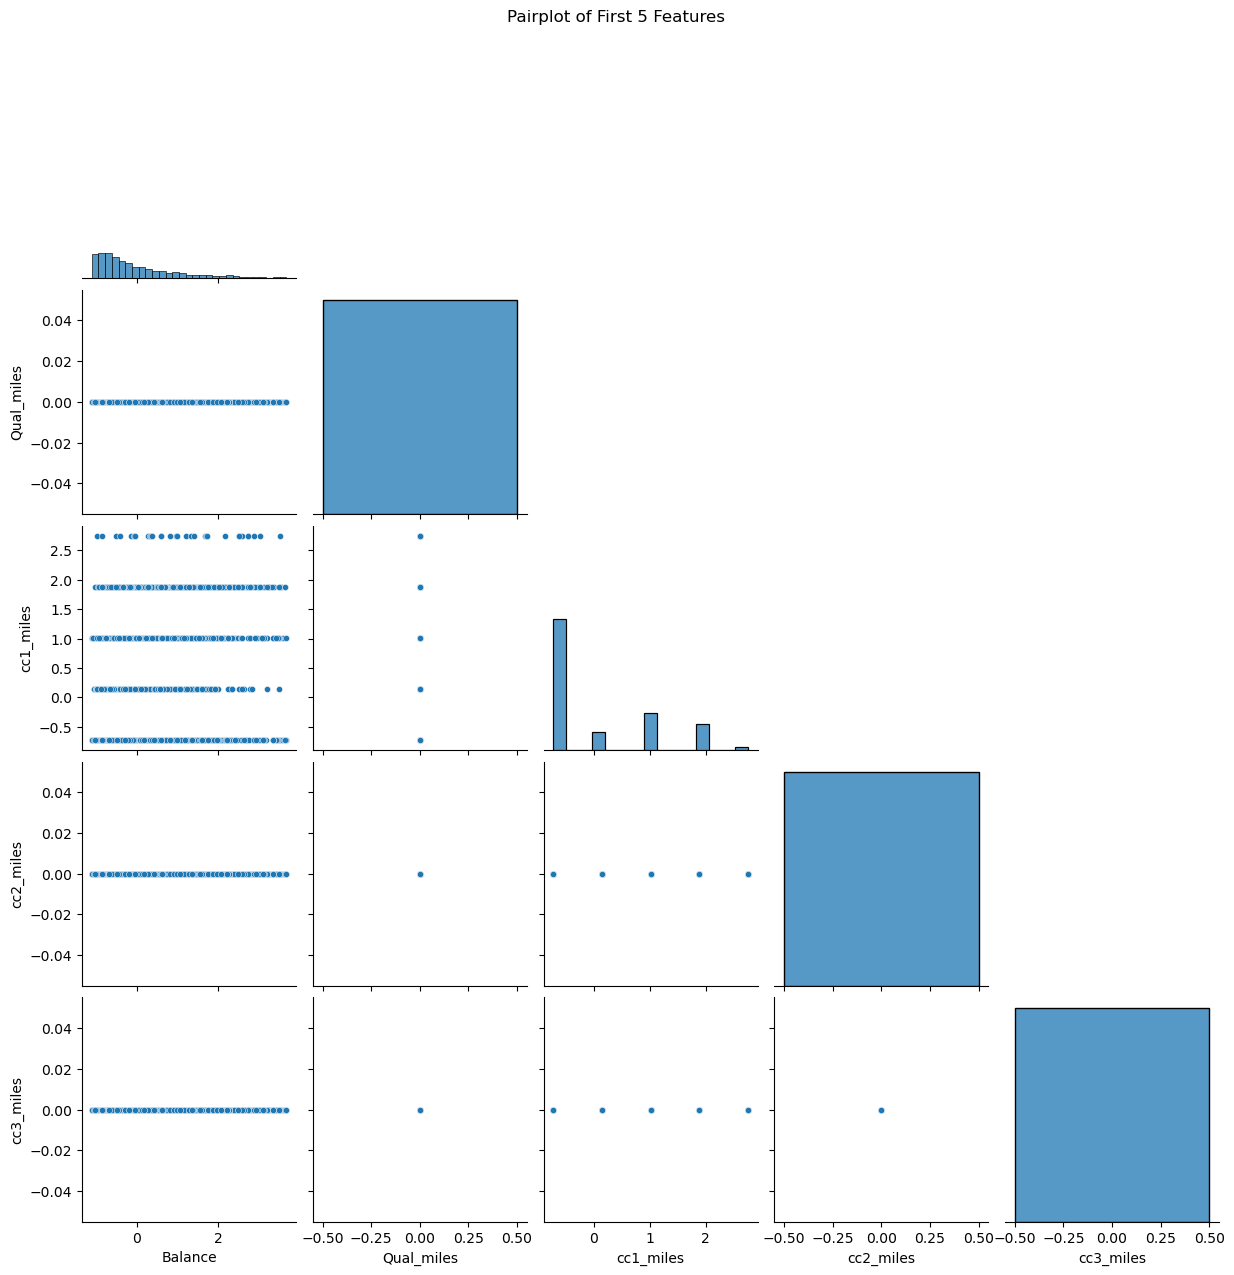

In [19]:
# Scatter Plots
# Sample 500 rows for faster plotting

sns.pairplot(df_scaled[df_scaled.columns[:5]], corner=True, plot_kws={'s':20})
plt.suptitle('Pairplot of First 5 Features', y=1.02)
plt.show()


C:\Users\Bibhuprasad Das\AppData\Local\Temp\ipykernel_1504\3450400657.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_scaled[col], fill=True, color='red')
C:\Users\Bibhuprasad Das\AppData\Local\Temp\ipykernel_1504\3450400657.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_scaled[col], fill=True, color='red')
C:\Users\Bibhuprasad Das\AppData\Local\Temp\ipykernel_1504\3450400657.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_scaled[col], fill=True, color='red')


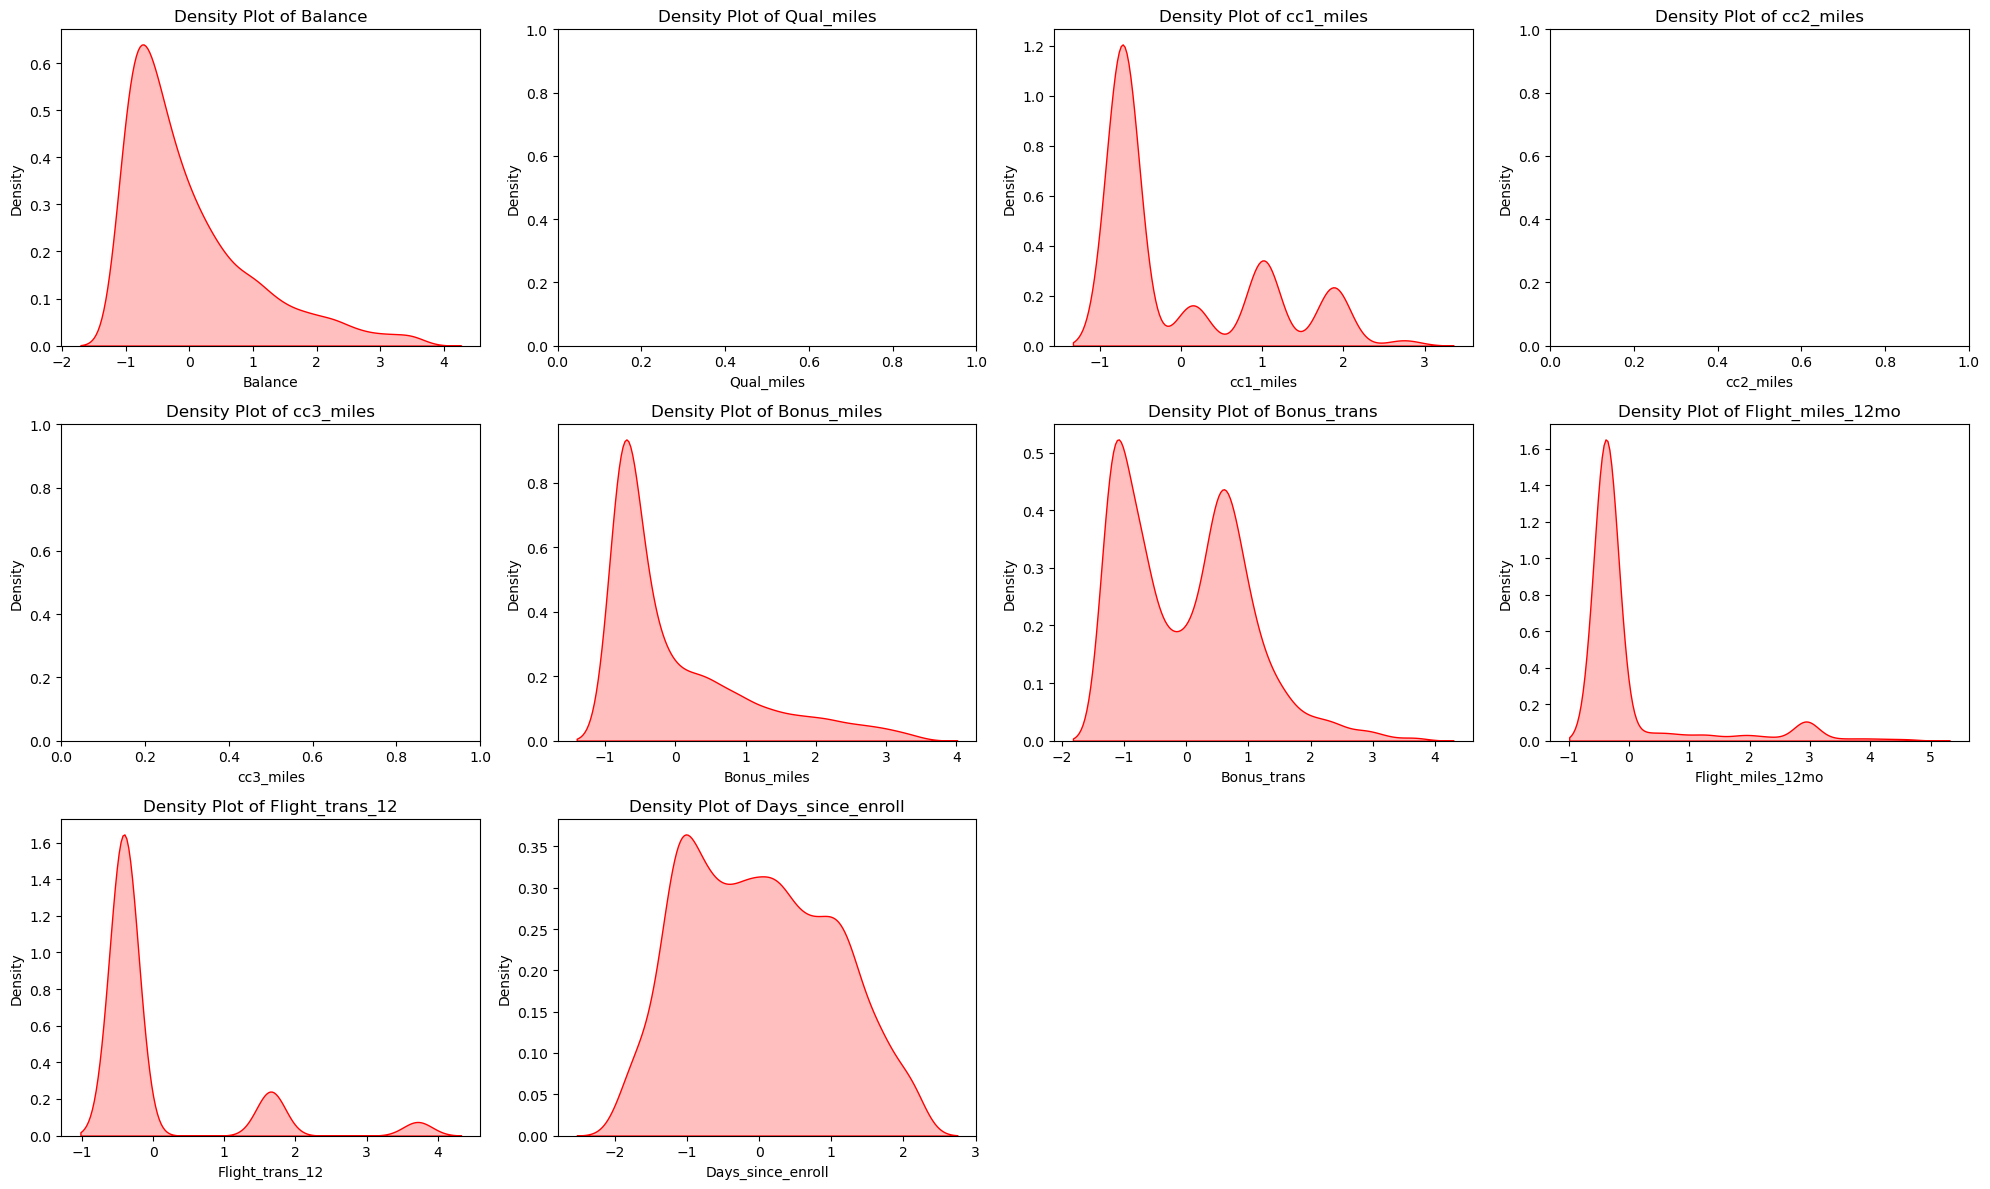

In [21]:
#KDE Plots (Density Estimation)
plt.figure(figsize=(20,12))
for i, col in enumerate(df_scaled.columns, 1):
    plt.subplot(3,4,i)
    sns.kdeplot(df_scaled[col], fill=True, color='red')
    plt.title(f'Density Plot of {col}')
plt.tight_layout()
plt.show()


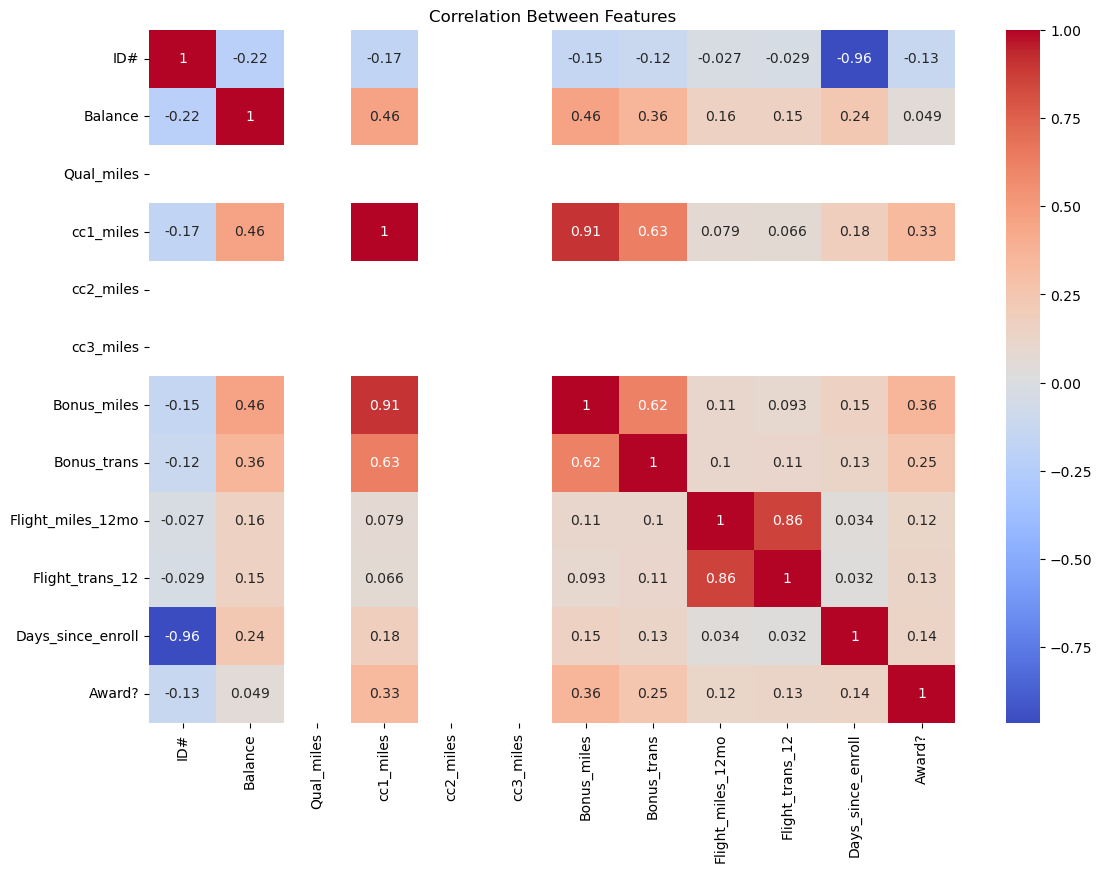

In [22]:
#Correlation
plt.figure(figsize=(13,9))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Features")
plt.show()

### PCA 2D Projection

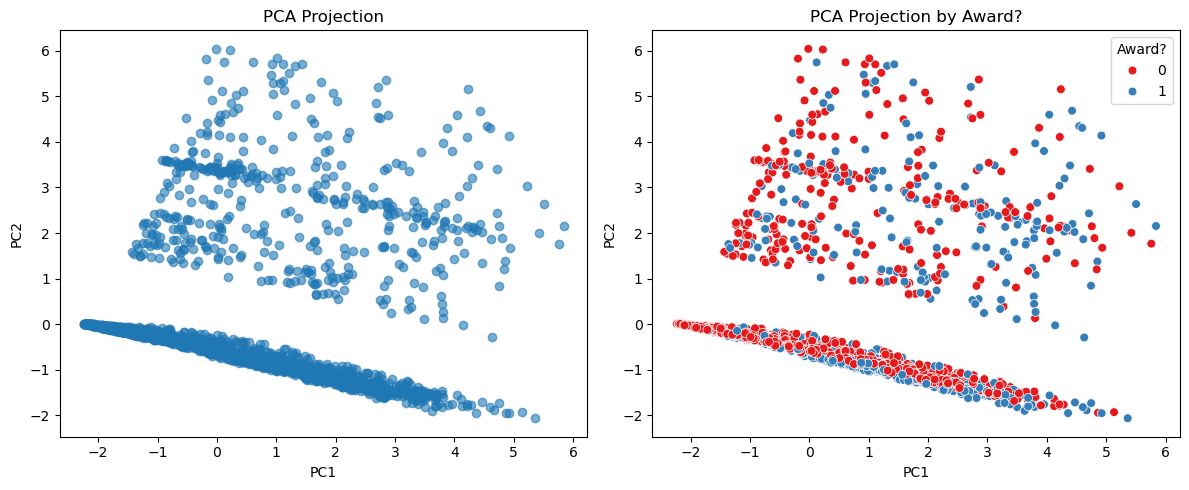

In [23]:
#2D PCA Projection of Dataset
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(12,5))

# Left: plain PCA
plt.subplot(1,2,1)
plt.scatter(df_pca[:,0], df_pca[:,1], alpha=0.6)
plt.title("PCA Projection")
plt.xlabel("PC1"); plt.ylabel("PC2")

# Right: PCA colored by Award?
plt.subplot(1,2,2)
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=df_clean['Award?'], palette="Set1", s=40)
plt.title("PCA Projection by Award?")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


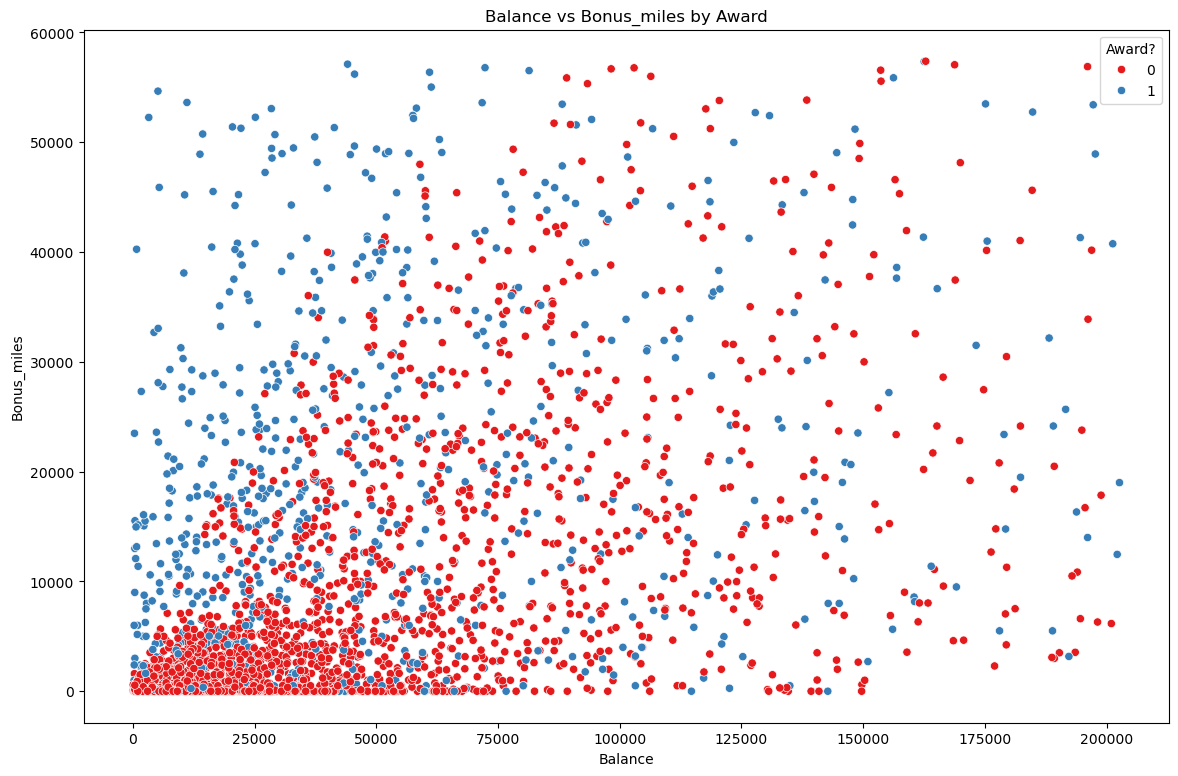

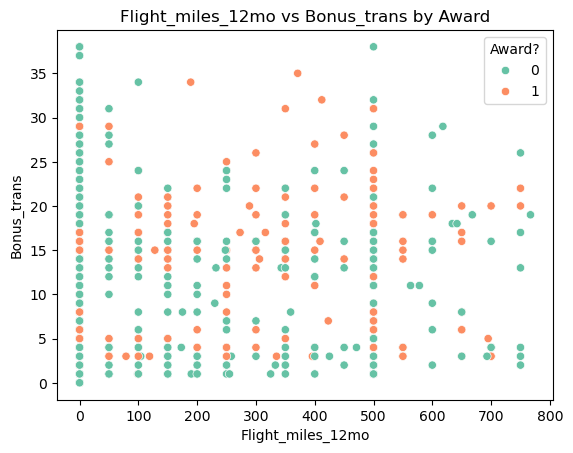

In [24]:
# Scatter plots to observe patterns
plt.figure(figsize=(14,9))
sns.scatterplot(x='Balance', y='Bonus_miles', data=df_clean, hue='Award?', palette='Set1')
plt.title("Balance vs Bonus_miles by Award")
plt.show()

sns.scatterplot(x='Flight_miles_12mo', y='Bonus_trans', data=df_clean, hue='Award?', palette='Set2')
plt.title("Flight_miles_12mo vs Bonus_trans by Award")
plt.show()


## Implementing Clustering Algorithms:

### K-Means Clustering

C:\Users\Bibhuprasad Das\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Bibhuprasad Das\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Bibhuprasad Das\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bibhuprasad Das\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Bibhuprasad Das\anaconda3\Lib\subprocess.py", line 1538, in _exec

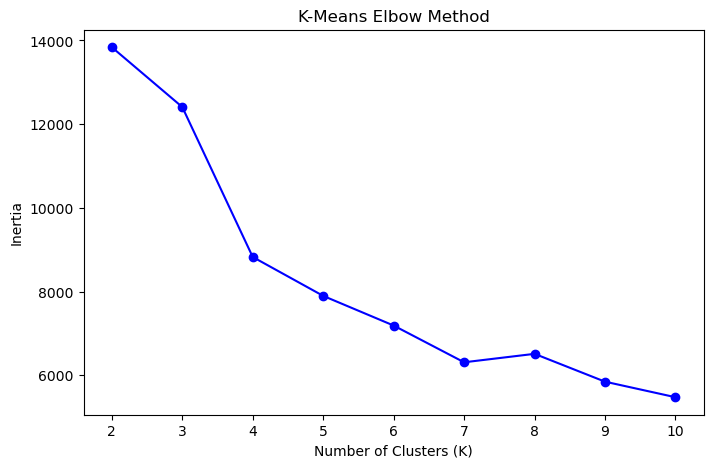

In [25]:
# Elbow method to select K
inertia = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.show()



**Cluster Selection Justification:**
From the elbow curve, the rate of decrease in WCSS slows after K=4, indicating that four clusters provide a good balance between model complexity and explained variance.

C:\Users\Bibhuprasad Das\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


K-Means Silhouette Score:
 0.272


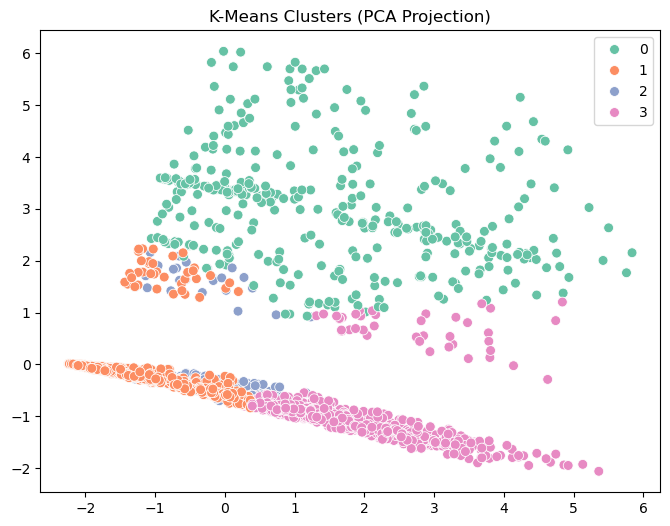

In [27]:
# Fit K-Means with optimal K=4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)
df_clean['KMeans_Cluster'] = kmeans_labels

# Silhouette score
kmeans_silhouette = silhouette_score(df_scaled, kmeans_labels)
print("K-Means Silhouette Score:\n", round(kmeans_silhouette,3))

# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=kmeans_labels, palette='Set2', s=50)
plt.title("K-Means Clusters (PCA Projection)")
plt.show()


### Hierarical Clustering

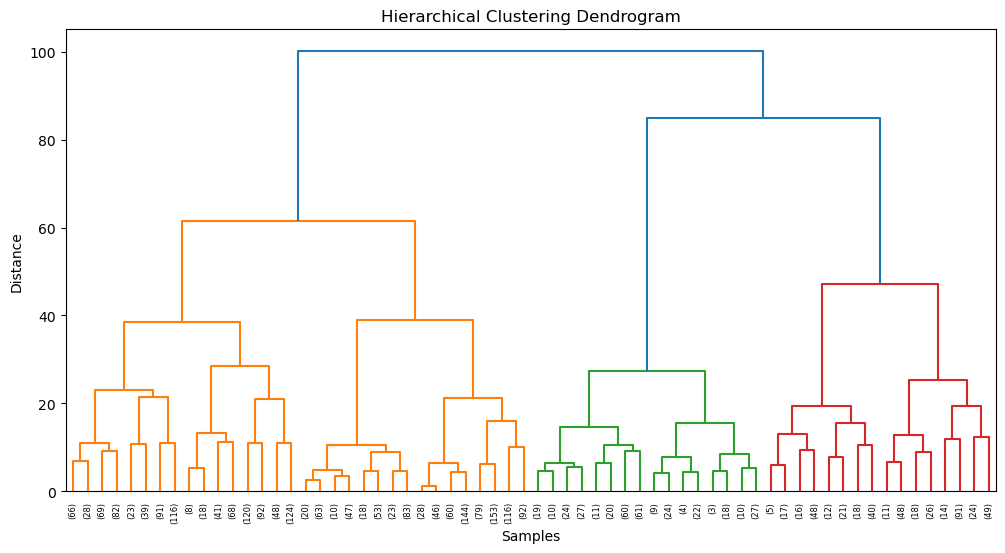

In [28]:
# Ward linkage
linked = linkage(df_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

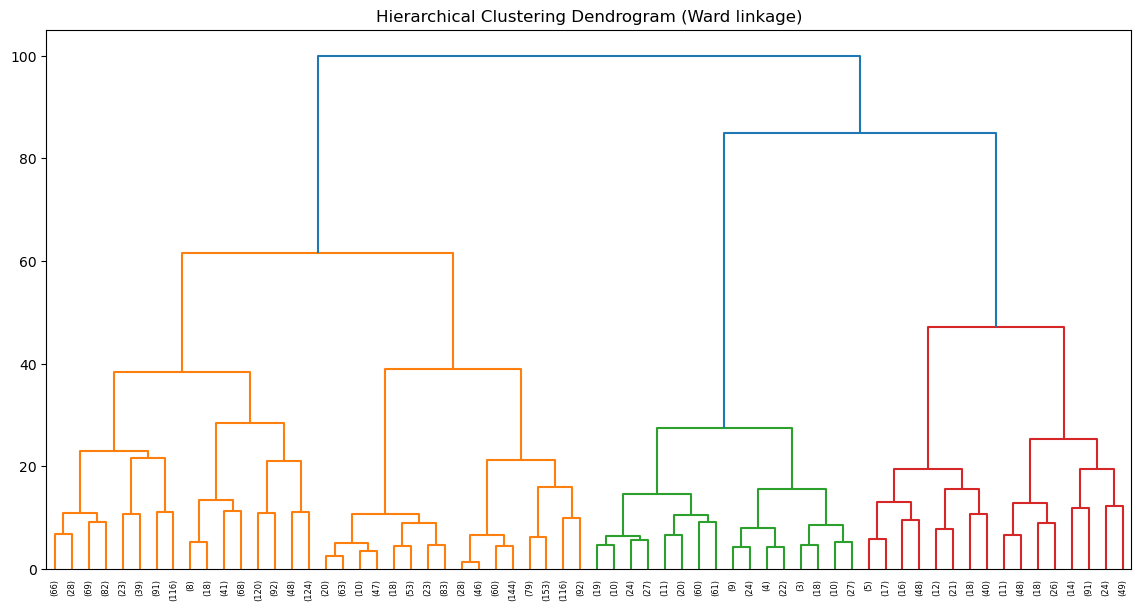


Ward linkage silhouette score: 
 0.231


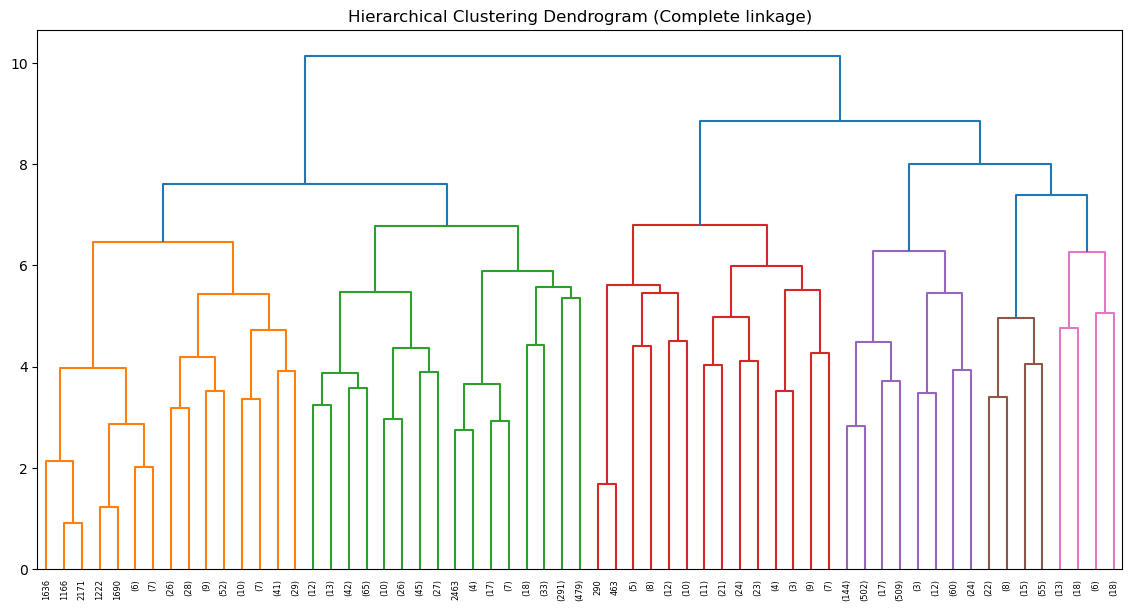


Complete linkage silhouette score: 
 0.271


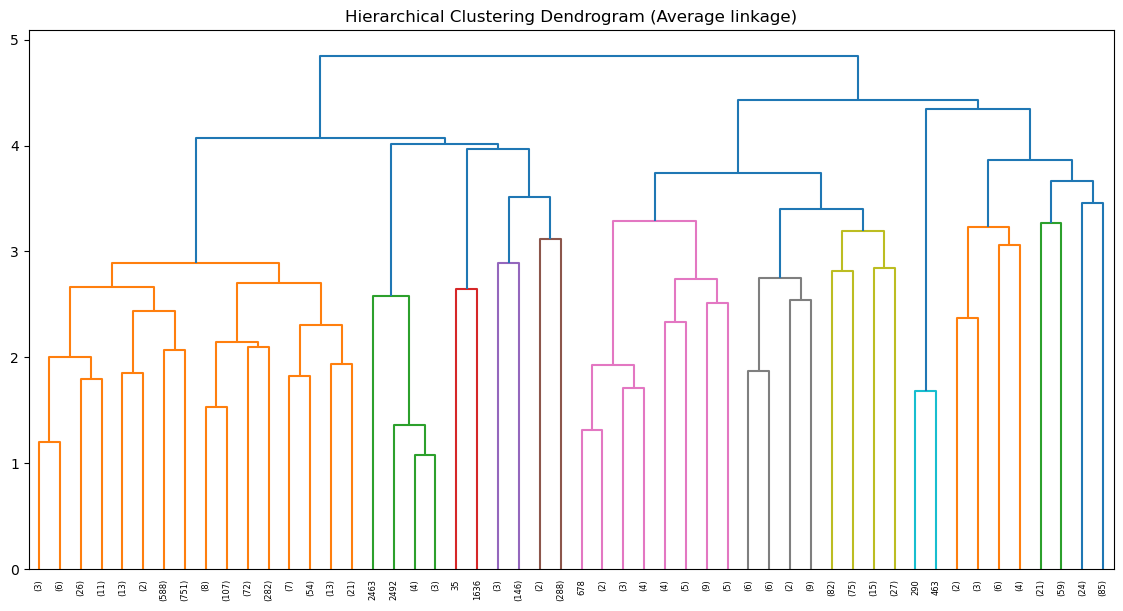


Average linkage silhouette score: 
 0.333


In [29]:
# Trying with different linkage methods
linkage_methods = ['ward', 'complete', 'average']
for method in linkage_methods:
    linked = linkage(df_scaled, method=method)

    plt.figure(figsize=(14,7))
    dendrogram(linked, truncate_mode='level', p=5)
    plt.title(f"Hierarchical Clustering Dendrogram ({method.capitalize()} linkage)")
    plt.show()

    # Assign 4 clusters for comparison
    hier_labels = fcluster(linked, 4, criterion='maxclust')
    silhouette = silhouette_score(df_scaled, hier_labels)
    print(f"\n{method.capitalize()} linkage silhouette score: \n", round(silhouette,3))


In [30]:
# Save final hierarchical cluster labels (using Ward linkage as final choice)
linked_final = linkage(df_scaled, method='ward')
hier_labels = fcluster(linked_final, 4, criterion='maxclust')
df_clean['Hierarchical_Cluster'] = hier_labels


### DBSCAN Clustering


DBSCAN Silhouette Score:
 0.324


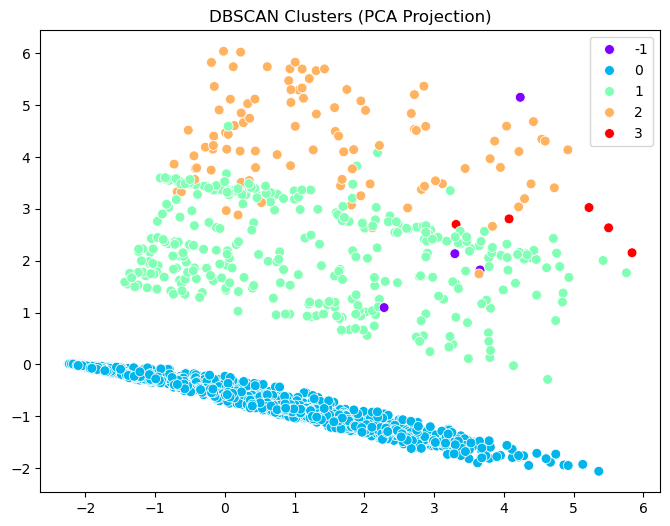

In [31]:
# Try different eps and min_samples
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)
df_clean['DBSCAN_Cluster'] = dbscan_labels

# Silhouette score (excluding noise points)
mask = dbscan_labels != -1
dbscan_silhouette = silhouette_score(df_scaled[mask], dbscan_labels[mask])
print("\nDBSCAN Silhouette Score:\n", round(dbscan_silhouette,3))

# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=dbscan_labels, palette='rainbow', s=50)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.show()

In [32]:
#Evaluation and Performance Metrics:
print("K-Means cluster counts:\n", df_clean['KMeans_Cluster'].value_counts())
print("\nHierarchical cluster counts:\n", df_clean['Hierarchical_Cluster'].value_counts())
print("\nDBSCAN cluster counts (including noise -1):\n", df_clean['DBSCAN_Cluster'].value_counts())


K-Means cluster counts:
 KMeans_Cluster
1    970
3    774
2    770
0    361
Name: count, dtype: int64

Hierarchical cluster counts:
 Hierarchical_Cluster
2    1035
1    1033
4     458
3     349
Name: count, dtype: int64

DBSCAN cluster counts (including noise -1):
 DBSCAN_Cluster
 0    2413
 1     352
 2     101
 3       5
-1       4
Name: count, dtype: int64


### K-Means Cluster Analysis and Visualization:

The K-Means clustering results show distinct customer segments based on their balance, miles, and activity. Cluster 0 represents high-value customers with high balances, bonus miles, and frequent flights, while Clusters 1 and 2 include low to medium-value users with lower activity and fewer miles. Cluster 3 shows customers with moderate balances but higher bonus miles and flight activity. Overall, the clusters reveal meaningful differences in customer behavior and loyalty patterns.

                        ID#       Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                
0               2023.445983  64534.853186         0.0   2.055402        1.0   
1               3152.618557  26101.131959         0.0   1.093814        1.0   
2               1125.461039  35443.835065         0.0   1.138961        1.0   
3               1837.348837  75915.921189         0.0   3.334625        1.0   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                     1.0  14319.565097    11.825485         422.382271   
1                     1.0   2945.630928     5.546392           4.402062   
2                     1.0   3415.587013     6.168831           3.470130   
3                     1.0  26618.925065    16.259690           6.069767   

                Flight_trans_12  Days_since_enroll    Award?  \
KMeans_Clu

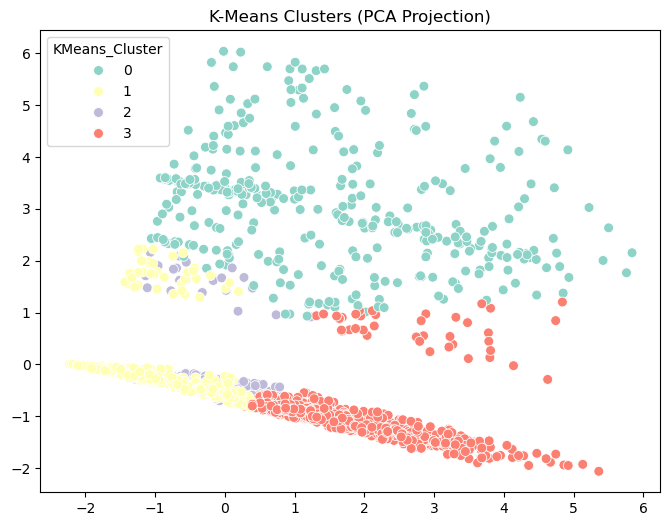

In [34]:
print(df_clean.groupby('KMeans_Cluster').mean())

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=df_clean['KMeans_Cluster'], palette='Set3', s=50)
plt.title("K-Means Clusters (PCA Projection)")
plt.show()


* Cluster 0: Low balance, low bonus miles, few flights – likely occasional users.
* Cluster 1: High balance, high bonus miles, frequent flights – loyal/high-value customers.
* Cluster 2: Medium balance and miles – moderate users.
* Cluster 3: Very high bonus miles but low flight activity – possibly credit card reward maximizers.


### Hierarchical Cluster Analysis and Visualization:

The Hierarchical clustering divides customers into segments with clear behavioral differences. Cluster 3 represents high-value customers with high balances and bonus miles, while Cluster 2 includes low-activity, low-balance users. Clusters 1 and 4 show moderate balances and activity, with varying bonus miles and flight behavior. These clusters reveal patterns in customer loyalty and engagement across the dataset.

                              ID#       Balance  Qual_miles  cc1_miles  \
Hierarchical_Cluster                                                     
1                     2169.096805  46779.516941         0.0   1.875121   
2                     2268.674396  24694.864734         0.0   1.000000   
3                     1613.140401  92832.484241         0.0   3.862464   
4                     2020.689956  61975.748908         0.0   2.054585   

                      cc2_miles  cc3_miles   Bonus_miles  Bonus_trans  \
Hierarchical_Cluster                                                    
1                           1.0        1.0  10643.494676    13.639884   
2                           1.0        1.0   1212.162319     1.790338   
3                           1.0        1.0  35591.217765    16.859599   
4                           1.0        1.0  14386.510917    11.259825   

                      Flight_miles_12mo  Flight_trans_12  Days_since_enroll  \
Hierarchical_Cluster                 

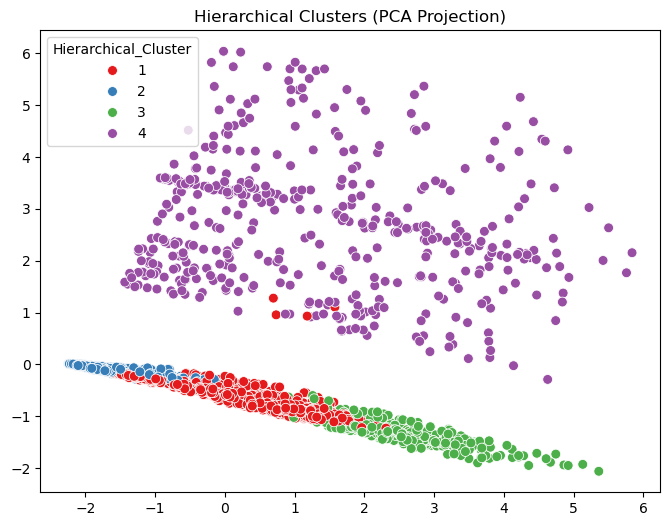

In [38]:
print(df_clean.groupby('Hierarchical_Cluster').mean())

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], 
                hue=df_clean['Hierarchical_Cluster'], 
                palette='Set1', s=50)
plt.title("Hierarchical Clusters (PCA Projection)")
plt.show()


* Cluster 1: High balance and high flight miles – premium users.
* Cluster 2: Low balance, minimal bonus – infrequent users.
* Cluster 3: Medium balance and flights – occasional users.
* Cluster 4: Very high flights but medium balance – frequent flyer program enthusiasts.


### DBSCAN Cluster Analysis and Visualization:

DBSCAN clustering identifies dense customer groups and outliers (-1). Cluster 3 and -1 include high-value customers with high balances, bonus miles, and flight activity, while clusters 0, 1, and 2 represent moderate-value users with lower activity. This highlights both core customer segments and unusual or extreme cases in the dataset.

                        ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
DBSCAN_Cluster                                                                 
-1              2294.500000  102443.750000         0.0   3.250000        1.0   
 0              2132.181931   43955.393701         0.0   1.788645        1.0   
 1              1991.752841   60694.068182         0.0   2.090909        1.0   
 2              2139.049505   59391.396040         0.0   1.752475        1.0   
 3              1188.600000  165774.600000         0.0   3.800000        1.0   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
DBSCAN_Cluster                                                            
-1                    1.0  23561.500000    24.000000         289.000000   
 0                    1.0  10213.673850     8.997513           0.000000   
 1                    1.0  14871.096591    11.167614         326.886364   
 2                    1.0  10883.336634    11.316832         459

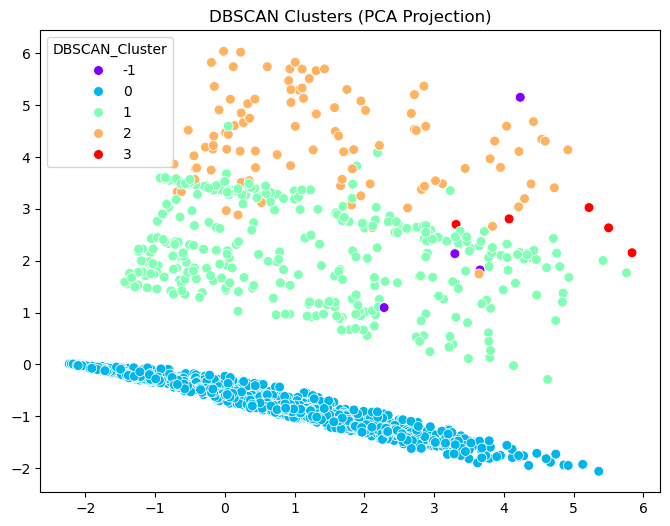

In [39]:
print(df_clean.groupby('DBSCAN_Cluster').mean())

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=df_clean['DBSCAN_Cluster'], palette='rainbow', s=50)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.show()


* Cluster 0: Dense cluster of medium-value users.
* Cluster 1: High-value users with high balances and bonus miles.
* Cluster -1: Noise points – outliers with extreme values (e.g., very high balance or miles).
* Cluster 2: Low-value users, infrequent flyers.


### Evaluation and Performance Metrics:

In [46]:
from sklearn.metrics import silhouette_score

# K-Means
kmeans_sil = silhouette_score(df_scaled, df_clean['KMeans_Cluster'])
print("K-Means Silhouette Score:", round(kmeans_sil, 3))


# Hierarchical
hier_sil = silhouette_score(df_scaled, df_clean['Hierarchical_Cluster'])
print("Hierarchical Silhouette Score:", round(hier_sil, 3))


# DBSCAN (remove noise points: -1)
mask = df_clean['DBSCAN_Cluster'] != -1

if len(set(df_clean['DBSCAN_Cluster'][mask])) > 1:
    dbscan_sil = silhouette_score(
        df_scaled[mask],
        df_clean['DBSCAN_Cluster'][mask]
    )
    print("DBSCAN Silhouette Score:", round(dbscan_sil, 3))
else:
    print("DBSCAN produced less than 2 clusters — silhouette score not valid.")

K-Means Silhouette Score: 0.272
Hierarchical Silhouette Score: 0.231
DBSCAN Silhouette Score: 0.324


## Conclusion

In this analysis, three clustering algorithms — K-Means, Hierarchical Clustering, and DBSCAN — were applied to the EastWest Airlines customer dataset to identify meaningful customer segments.

After preprocessing, outlier treatment, and feature scaling, clustering was performed and evaluated using the Silhouette Score.

Among the three clustering techniques, DBSCAN achieved the highest silhouette score (0.324), indicating better cluster separation compared to K-Means (0.272) and Hierarchical clustering (0.231). However, K-Means produced more interpretable and balanced customer segments. Therefore, while DBSCAN shows better mathematical separation, K-Means may be more suitable for practical business segmentation.

The analysis revealed distinct customer segments such as:
- High-value frequent flyers with high balances and bonus miles
- Moderate users with regular activity
- Low-engagement customers
- Outliers with extreme behavior patterns

  
Overall, clustering successfully uncovered hidden patterns in customer behavior and demonstrated how unsupervised learning can support data-driven decision-making in the airline industry.
